# 8. Pulses and shots files

`sylva.Shots` stores pulses rather than points: an origin and direction per
pulse, with a CSR list of echo ranges. Pulses without a return stay in the data,
because they say where there was nothing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import Shots

In [2]:
scene = synthetic.forest()
shots = synthetic.scan(scene, origin=(10.0, 10.0, 1.5), resolution_deg=0.2)
print(shots)
print("echoes per pulse:", dict(enumerate(np.bincount(shots.echo_count))))
print("echo attributes:", sorted(shots.echo_attrs))

Shots(n_shots=1,170,000, n_echoes=93,656)
echoes per pulse: {0: np.int64(1085194), 1: np.int64(75956), 2: np.int64(8850)}
echo attributes: ['classification', 'tree_id']


The echo arrays are flat; `echo_start` / `echo_count` say which belong to which pulse.

In [3]:
s = int(np.flatnonzero(shots.echo_count == 2)[0])
a = shots.echo_start[s]
print("pulse", s, "direction", np.round(shots.direction[s], 3), "ranges", np.round(shots.echo_range[a:a + 2], 2))
zen, az = shots.zenith_azimuth()
first = shots.echo_rank() == 0
print("first returns:", first.sum(), " later returns:", (~first).sum())

pulse 70210 direction [0.005 0.139 0.99 ] ranges [12.82 13.92]
first returns: 84806  later returns: 8850


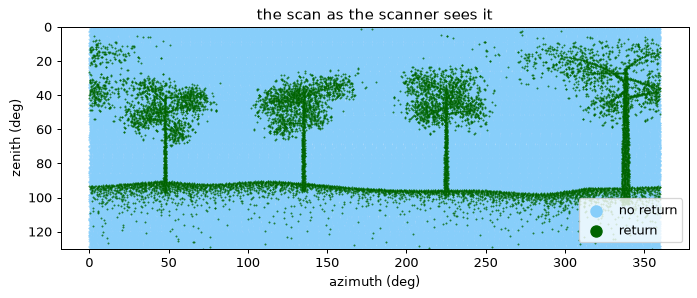

In [4]:
hit = shots.echo_count > 0
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.scatter(az[~hit][::7], zen[~hit][::7], s=0.2, c="lightskyblue", label="no return")
ax.scatter(az[hit][::7], zen[hit][::7], s=0.2, c="darkgreen", label="return")
ax.set(xlabel="azimuth (deg)", ylabel="zenith (deg)", ylim=(130, 0), title="the scan as the scanner sees it")
ax.legend(markerscale=20, loc="lower right");

Conversions: `to_pointcloud` gives the echoes as points (with `return_number`, `number_of_returns`, `range`); `from_pointcloud` and `from_ray_cloud` go the other way; `transform`, `subset` and `concatenate` behave as for point clouds.

In [5]:
points = shots.to_pointcloud()
upward = shots.subset(zen < 60)
both = Shots.concatenate([shots, synthetic.scan(scene, origin=(4.0, 16.0, 1.5), resolution_deg=0.2)])
print(points, upward, both, sep="\n")

PointCloud(n=93,656, attrs=['classification', 'number_of_returns', 'range', 'return_number', 'tree_id'])
Shots(n_shots=540,000, n_echoes=53,900)
Shots(n_shots=2,340,000, n_echoes=171,073)


## Shots files

`save` writes a Parquet file with one row per pulse: a scan index, two beam
angles and list columns for the echoes. A pulse without a return costs its two
angles and nothing else. Compare with storing the same pulses as a ray cloud,
where every miss is a far point carrying all the attributes.

In [6]:
import tempfile, pathlib
tmp = pathlib.Path(tempfile.mkdtemp())
both.save(tmp / "plot.parquet")

# The same pulses as a LAZ ray cloud: echoes, plus a point 100 m out for each miss.
miss = both.echo_count == 0
far = both.origin[miss] + 100 * both.direction[miss]
first_echo = both.echo_start[~miss]
ends = np.vstack([both.echo_xyz(), far])
starts = np.vstack([both.origin[both.shot_of_echo()], both.origin[miss]])
bound = np.r_[np.ones(both.n_echoes, np.uint8), np.zeros(miss.sum(), np.uint8)]
off = (starts - ends).astype(np.float32)
sylva.write(sylva.PointCloud(ends, {"sx": off[:, 0], "sy": off[:, 1], "sz": off[:, 2], "bound": bound}), tmp / "rays.laz")
for f in ("plot.parquet", "rays.laz"):
    print(f"{f:13s} {(tmp / f).stat().st_size / 1e6:6.2f} MB")

plot.parquet    3.04 MB
rays.laz       14.47 MB


In [7]:
info = Shots.file_info(tmp / "plot.parquet")
print({k: v for k, v in info.items() if k != "scans"})
print("scanner positions:\n", info["scans"])
back = Shots.load(tmp / "plot.parquet")
print("max echo position error after the float32 round trip:", f"{np.abs(back.echo_xyz() - both.echo_xyz()).max() * 1000:.3f} mm")

{'n_shots': 2340000, 'n_echoes': 171073, 'n_groups': 3, 'bounds': ([-3.999902232447462, -3.999157636987679, -0.41512358970029517], [23.99961601916641, 23.999387099936886, 18.056058061909813]), 'echo_attrs': ['classification', 'tree_id']}
scanner positions:
 [[10.  10.   1.5]
 [ 4.  16.   1.5]]
max echo position error after the float32 round trip: 0.003 mm


Any Parquet reader opens the file (polars, pyarrow, duckdb, R arrow). Row groups can be read one at a time with `Shots.load(path, groups=[...])`, and `sylva.voxels.ray_voxelize` accepts the path and streams it (notebook 9).